# 0 - Deep Learning

En la década del 2010, empezó lo que denominamos como Deep Learning. La plena adopción de la digitalización (smartphones, páginas webs,...) y el Big Data hizo que cada vez se almacenase más y más información de caracter no estructurado (textos, imágenes, vídeos,...).

Esto junto con los avances en la informática fomentó el auge de las redes neuronales para problemas más complejos que los de Machine Learning tradicional, que tenían como objetivo entender y generar datos como textos, imágenes

## Caso de éxito - Zalando

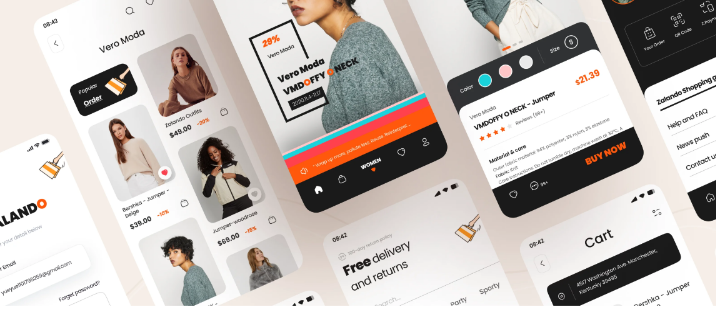

Zalando es una tienda de ropa online que opera en Europa. Uno de los factores diferenciales de Zalando desde la perspectiva tecnológica ha sido el uso del Deep Learning para la clasificación de reviews/email de clientes así como la generación de contenido (imágenes y textos)

> **NOTA**: Zalando no es la única empresa digital que se enfrentó a este problema, sin embargo, es conocido en la industria de IA por ser una de las empresas europeas por tener mayor adopción del Deep Learning. Prueba de ello son las contribuciones de [ZalandoResearch](https://github.com/zalandoresearch)

# 1 - Redes neuronales

Una red neuronal es un tipo de algoritmo de Machine Learning similar a cualquier otro que hayamos visto anteriormente. Su característica fundamental es que nació de intentar "imitar" cómo se transmite la información a través de las neuronas en un cerebro humano.

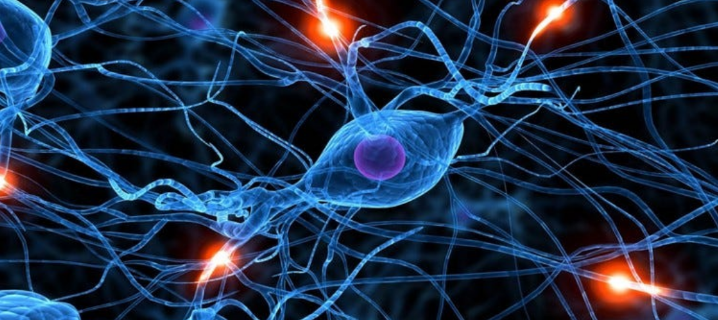

## 1.1 - Componentes

### Neurona

Las redes neuronales están compuestas por "pequeños modelos" individuales similares a una regresión lineal (aunque distinto) que tratan de aprender de manera independiente. Estos modelos es lo que se denominan "neuronas". Concretamente le algoritmo en el que se basan las neuronas se denomina perceptón

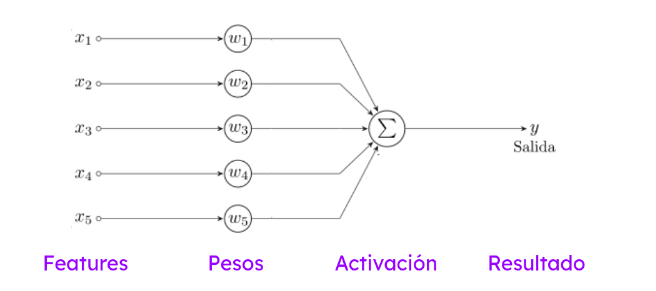

> **NOTA**: Historicamente en el mundo de la IA, el concepto de neurona viene de un modelo anterior denominado [perceptrón](https://es.wikipedia.org/wiki/Perceptr%C3%B3n)

**Función de activación**

La función de activación es una función matemática que tiene cada neurona para definir el tipo de salida que espera. Es mucho más complejo que todo esto, pero sin entrar mucho en detalle, para las neuronas internas es común usar funciones de activación "relu" mientras que para las neuronas de la última capa se suele usar "softmax" o "sigmoid" si es un problema de clasificación o "linear" si es de regressión

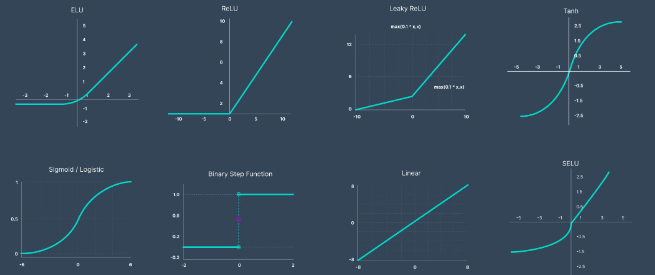

**Función de loss**

Igual que en el ML, la función de loss sirve para medir cómo de bien funciona un modelo. En el Deep Learning es especialmente importante ya que la función de loss **define cómo aprende el modelo**

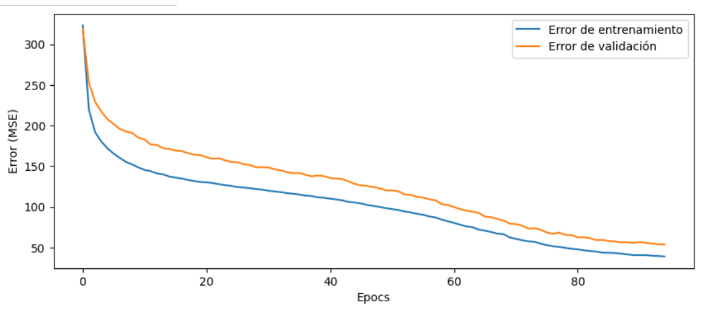

**Optimizador**

Función matemática que define cómo aprende la Red Neuronal a partir del loss. Existen diferentes optimizadores, algunos de ellos son:

* **SDG**

* **RMSprop**

* **Adam**

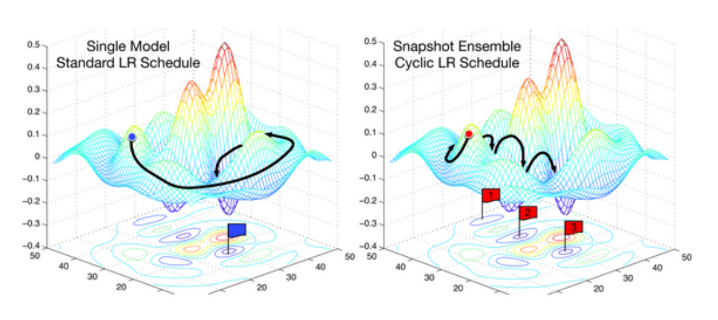

**Ejemplo**

In [1]:
import numpy as np

class Perceptron:
    def __init__(self, n_inputs, lr=0.5, epochs=10):

        # Parametros
        self.w = np.random.uniform(-1, 1, n_inputs)
        self.b = np.random.uniform(-1, 1)

        # Hiperparametros
        self.lr = lr
        self.epochs = epochs

    def activation(self, z):
        """
        Función de activación - Sigmoide
        """
        return 1 / (1 + np.exp(-z))

    def predict(self, features):
        return self.activation(np.dot(features, self.w) + self.b)

    def loss(self, y_true, y_pred):
        """
        Función de loss - MSE
        """
        return np.mean((y_true - y_pred) ** 2)

    def optimizer(self, X, y_true, y_pred):
        """
        Optimizador - SGD
        """
        error = y_true - y_pred
        gradient_act = y_pred * (1 - y_pred)

        self.w += self.lr * np.dot(X.T, error * gradient_act)
        self.b += self.lr * np.sum(error * gradient_act)

    def train(self, features, labels):
        for epoch in range(self.epochs):

            # Predicción
            predictions = self.predict(X)

            # Cálculo de error
            current_loss = self.loss(labels, predictions)

            # Optimización
            self.optimizer(features, labels, predictions)

            print(f"Época {epoch} - Loss: {current_loss:.6f}")

In [2]:
# --- Datos de entrenamiento (Compuerta AND) ---
X = np.array([[0,0], [0,1], [1,0], [1,1]])
y = np.array([0, 0, 0, 1])

modelo = Perceptron(n_inputs=2)
modelo.train(X, y)

print("\nPredicciones finales:")
print(modelo.predict(X))

Época 0 - Loss: 0.220419
Época 1 - Loss: 0.201254
Época 2 - Loss: 0.187836
Época 3 - Loss: 0.178232
Época 4 - Loss: 0.171053
Época 5 - Loss: 0.165407
Época 6 - Loss: 0.160745
Época 7 - Loss: 0.156731
Época 8 - Loss: 0.153159
Época 9 - Loss: 0.149901

Predicciones finales:
[0.24679476 0.40834263 0.31038745 0.48666593]


### Red Neuronal

La red neuronal se construye a partir de conectar diferentes neuronas. Según cómo las conectemos es cómo aparecen los diferentes tipos de redes neuronales

**Red Neuronal Densa (DNN)**

Según como conectemos neuronas, se pueden generar muchas configuraciones de redes de neuronas. En particular, se denomina red neuronal densa cuando organizamos las neuronas por capas y conectamos las neuronas de una capa con la siguiente

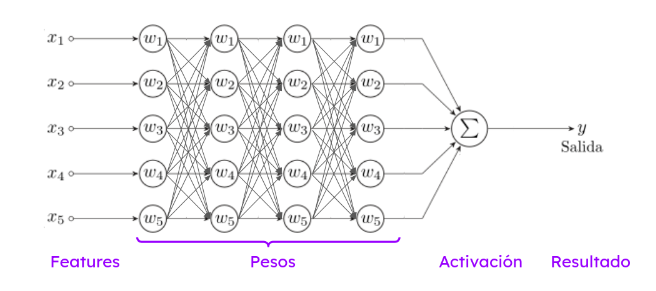

> **NOTA**: En este curso nos vamos a centrar únicamente en estas ya que son la base de los LLMs

**Red Neuronal Recurrente (RNN)**

Se denomina red recurrente a las redes neuronales cuyas salidas sirven como entradas a la red o neuronas anteriores

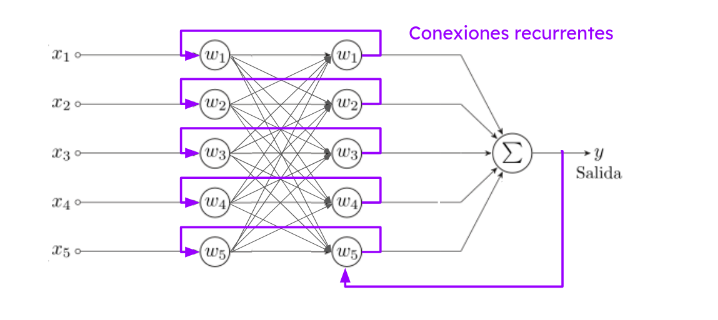

> **NOTA** Estas redes fueron muy populares en los primeros sistemas de traducción automática basado en IA

**Red Neuronal Convolucional (CNN)**

Redes neuronales que permite procesar imágenes y vídeos a partir de "recorrer" (convolucionar) los pixeles de una imagen

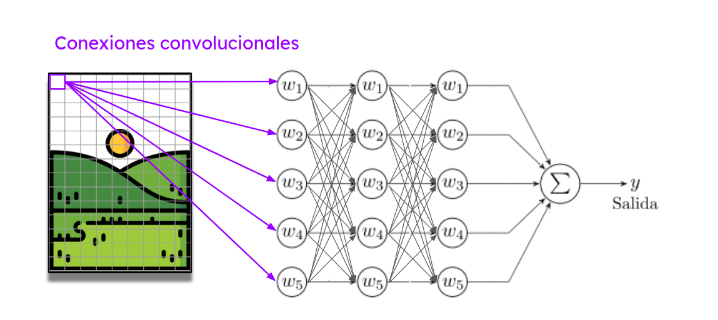

> **NOTA**: Aunque estas redes se usan princiapelmente para el procesamiento de imágenes, a veces también se usan para otros propósitos (como el lenguaje)

### Hiperparámetros

**Número de neuronas**

El número de neuronas que componen la red. Generalmente lo que se suele configurar es el número de neuronas que tiene cada capa de la red. Generalmente se suele tener entre 30 y 200 neuronas por capa.

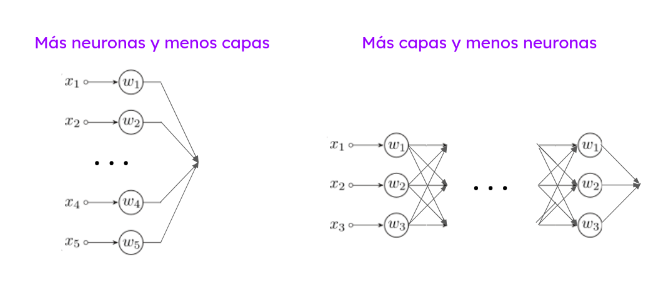

**Número de capas**

Las neuronas de una red neuronal se agrupan en capas. No hay una regla exacta para saber cuántas capas debería tener una red neuronal, pero una buena "intuición" es que cuanto más "abstracto" sea el problema más capas suele tener. Un modelo de clasificación numérica suele tener 2-3 capas, mientras que un modelo de detección de objetos en imagen suele tener 10-12 capas y un modelo como ChatGPT suele tener cientos de capas.

**Batch Size**

En cada iteración, la red neuronal coge una "muestra pequeña" de los datos para hacer la actualización de los parámetros. El tamaño de esa muestra suele ser de algún tamaño potencia de 2 de entre 30 y 300 (32,64,128,256)

**Learning rate**

Las redes neuronales aprenden a través de una proceso iterativo. En cada iteración optimizan sus parámetros para dar mejores resultados. El learning rate sirve para definir "cuánto aprenden" en cada iteración. Su valor suele estar entre 0.1 y 0.001. Si quieres que aprendan más rápido, es mejor un valor cercano a 0.1, si quieres que aprendan más lento es mejor un valor cercano a 0.01

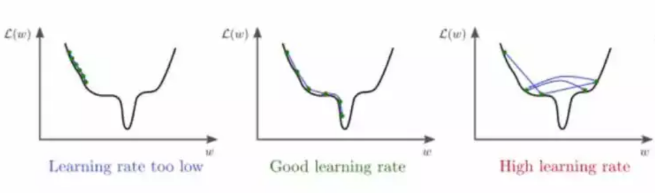

**Epochs**

Además de recorrer el dataset por "muestras" es común recorrer el dataset varias veces en un mismo entrenamiento. El número de veces que se recorre el dataset en unentrenamiento se denomina "epochs". Generalmente se suele coger un valor de entre 10 y 100. Generalmente cuanto más alto mejor, pero muchas veces más alto no mejora el resultado y supone aumentar el tiempo de espera de entrenamiento

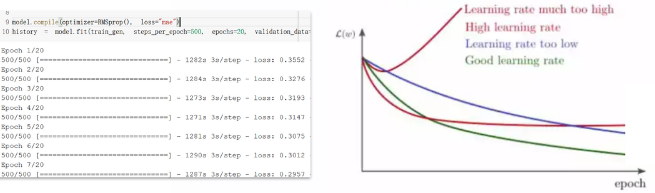

### ¿Por qué tan popular?

El principal motivo por el que las redes neuronales se han vuelto tan populares es porque a partir de "apilar" neuronas podemos hacer redes más y más grandes que continúan aprendiendo. Generalmente en los modelos de ML tradicional algoritmos más grandes no dan mejores resultados mientras que en el caso de las redes neuronales sí

![]( 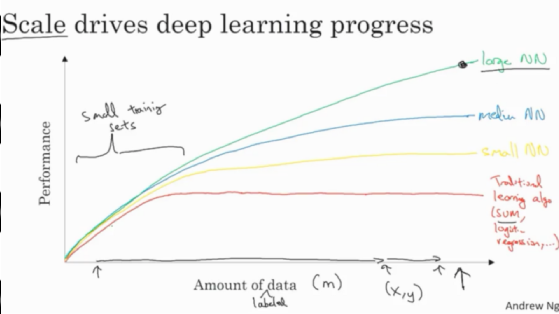)

<br>

## 1.2 - Modelo de regresión

Existen diferentes librerías para hacer deep learning en Python (Tensorflow, Keras, Caffe, PyTorch,...). Para los ejemplos que vamos a ver en este curso vamos a centrarnos en Keras, porque es uno de los frameworks más extendidos que al mismo tiempo requiere menor conocimiento matemático para ser usado.

### Dataset - Concrete Strength

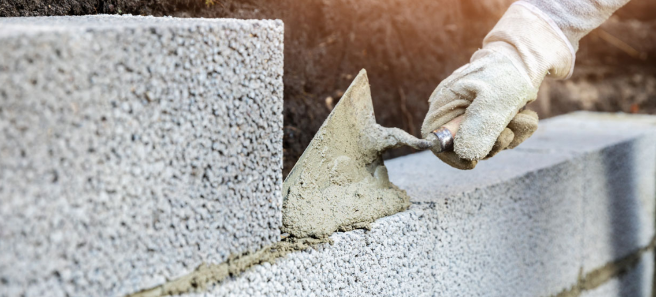

In [3]:
import pandas as pd

url = 'https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/refs/heads/master/concrete.csv'
data = pd.read_csv(url)
data

,cement,slag,ash,water,superplastic,coarseagg,fineagg,age,strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30
...,...,...,...,...,...,...,...,...,...
1025,276.4,116.0,90.3,179.6,8.9,870.1,768.3,28,44.28
1026,322.2,0.0,115.6,196.0,10.4,817.9,813.4,28,31.18
1027,148.5,139.4,108.6,192.7,6.1,892.4,780.0,28,23.70
1028,159.1,186.7,0.0,175.6,11.3,989.6,788.9,28,32.77


**Separación en train y test**

In [4]:
data = data.sample(n=len(data)*1) # si necesitamos un dataset más pequeño, multiplicar por menos en vez de por 1. Ej) 60% = *0.6

data_train = data[0:int(0.9*len(data))] # Tomamos el 90%
data_test = data[int(0.9*len(data)):]

X_train = data_train.drop("strength", axis=1)
y_train = data_train["strength"]

X_test = data_test.drop("strength", axis=1)
y_test = data_test["strength"]

### Preprocesamiento

In [5]:
from sklearn.preprocessing import StandardScaler

# Escalar las características (normalización)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

X_train

array([[-1.03973656,  0.48570151, -0.8484572 , ..., -0.34376765,
         1.05602099, -0.2816504 ],
       [-0.41347251, -0.85558067, -0.8484572 , ...,  1.89694927,
         0.20003025, -0.2816504 ],
       [ 1.86998258, -0.85558067, -0.8484572 , ..., -0.53747449,
        -2.26188999, -0.2816504 ],
       ...,
       [-1.23243319,  0.82102206,  0.91837765, ...,  0.37870649,
        -1.06249295, -0.2816504 ],
       [-1.27964387, -0.85558067,  1.28738033, ...,  0.37608883,
         0.71892729, -0.2816504 ],
       [-0.91255679,  0.57936001, -0.8484572 , ...,  1.44409409,
        -0.11181298, -0.61244306]], shape=(927, 8))

> **NOTA**: Las redes de neuronas, a diferencia de otros modelos, son muy sensibles a factores numéricos como la escala, y distribución. Es por ello por lo que suele ser muy necesario hacer un buen preprocesamiento para que funcionenn

### Modelo

In [6]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam


# Construcción del modelo
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),  # Capa oculta 1
    Dense(32, activation='relu'),                                   # Capa oculta 2
    Dense(1, activation='linear')                                   # Capa de salida
])

# Compilación del modelo
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae'],
)

# Entrenamiento del modelo
history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    verbose=1)


I0000 00:00:1772873736.996789   76860 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1772873737.000540   76860 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1772873737.398974   76860 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1772873738.828336   76860 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.

Epoch 1/100


/home/thinbaker/Workspace/Curso-de-IA-y-NLP/.venv/lib/python3.13/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1772873739.336858   76860 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 1555.8136 - mae: 35.6129 - val_loss: 1450.1583 - val_mae: 34.9368
Epoch 2/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1465.7223 - mae: 34.3074 - val_loss: 1331.9786 - val_mae: 33.2673
Epoch 3/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1313.1079 - mae: 32.1027 - val_loss: 1130.1719 - val_mae: 30.2468
Epoch 4/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1066.9679 - mae: 28.2457 - val_loss: 828.8476 - val_mae: 25.2195
Epoch 5/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 737.8096 - mae: 22.4782 - val_loss: 490.2970 - val_mae: 18.4767
Epoch 6/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 425.4664 - mae: 16.2863 - val_loss: 253.1023 - val_mae: 12.9379
Epoch 7/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 257.6112 - mae: 12.6982 - val_loss: 176.8703 - val_mae: 10.7224
Epoch 8/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 216.4501 - mae: 11.8728 - val_loss: 164.8724 - val_mae: 10.2562
Epoch 9/100
24/24 ━━━

### Evaluación

**Training loss**

Mean Absolute Error en el conjunto de prueba: 4.88


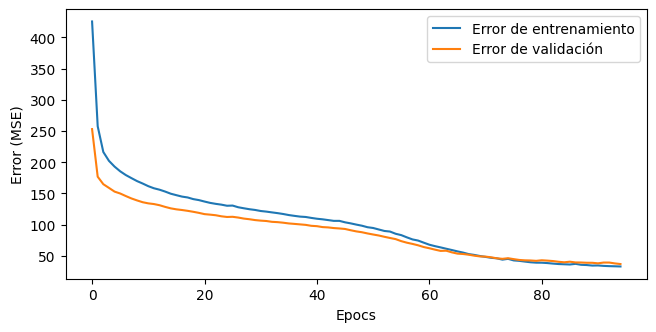

In [7]:
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = [7.5, 3.5]

# Evaluar el modelo
loss, mae = model.evaluate(X_test, y_test, verbose=0)
print(f"Mean Absolute Error en el conjunto de prueba: {mae:.2f}")

# Grafica
plt.plot(history.history['loss'][5:], label='Error de entrenamiento')
plt.plot(history.history['val_loss'][5:], label='Error de validación')
plt.xlabel('Epocs')
plt.ylabel('Error (MSE)')
plt.legend()
plt.show()

**Metrics**

In [8]:
from sklearn.metrics import r2_score
from sklearn.metrics import root_mean_squared_error

y_pred = model.predict(X_test)

print('r2 score', r2_score(y_test,y_pred))
print('rmse', root_mean_squared_error(y_test,y_pred))

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
r2 score 0.8482153772682541
rmse 6.688826982653048


## 1.3 - Modelo de clasificación - Iris dataset

### Dataset - Iris

In [9]:
import pandas as pd
url = 'https://gist.githubusercontent.com/curran/a08a1080b88344b0c8a7/raw/0e7a9b0a5d22642a06d3d5b9bcbad9890c8ee534/iris.csv'
data = pd.read_csv(url)
data = data.sample(n=len(data))
data

,sepal_length,sepal_width,petal_length,petal_width,species
94,5.6,2.7,4.2,1.3,versicolor
117,7.7,3.8,6.7,2.2,virginica
53,5.5,2.3,4.0,1.3,versicolor
138,6.0,3.0,4.8,1.8,virginica
59,5.2,2.7,3.9,1.4,versicolor
...,...,...,...,...,...
44,5.1,3.8,1.9,0.4,setosa
125,7.2,3.2,6.0,1.8,virginica
66,5.6,3.0,4.5,1.5,versicolor
95,5.7,3.0,4.2,1.2,versicolor


In [10]:
X = data.drop("species", axis=1)
y = data["species"]

X_train = X[0:int(0.9*len(data))]
y_train = y[0:int(0.9*len(data))]

X_test = X[int(0.9*len(data)):]
y_test = y[int(0.9*len(data)):]

### Preprocesamiento

**Label one-hot-encodding**

In [11]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(sparse_output=False)
y_train = encoder.fit_transform(y_train.to_numpy().reshape(-1, 1))
y_test = encoder.transform(y_test.to_numpy().reshape(-1, 1))
print(y_train[0:5])

[[0. 1. 0.]
 [0. 0. 1.]
 [0. 1. 0.]
 [0. 0. 1.]
 [0. 1. 0.]]


**Scaler**

In [12]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
X_test[0:5]

array([[-0.5492767 ,  0.82537203, -1.29815101, -1.07112601],
       [ 0.53061196, -0.345061  ,  1.02492233,  0.75597522],
       [ 0.65059959, -0.5791476 ,  1.02492233,  1.27800414],
       [-1.02922721, -2.45184044, -0.1649445 , -0.28808263],
       [-0.06932619, -0.81323421,  0.0616968 , -0.02706817]])

### Modelos DNN

In [13]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam


# Construcción del modelo
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),  # Capa oculta 1
    Dense(32, activation='relu'),                                   # Capa oculta 2
    Dense(y_train.shape[1], activation='softmax')                         # Capa de salida
])

# Compilación del modelo
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)

# Entrenamiento del modelo
history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=16,
    verbose=1,
)


Epoch 1/100


/home/thinbaker/Workspace/Curso-de-IA-y-NLP/.venv/lib/python3.13/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.6667 - loss: 0.9687 - val_accuracy: 0.7037 - val_loss: 0.8727
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6667 - loss: 0.8386 - val_accuracy: 0.7037 - val_loss: 0.7504
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6759 - loss: 0.7315 - val_accuracy: 0.7037 - val_loss: 0.6520
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6852 - loss: 0.6376 - val_accuracy: 0.8148 - val_loss: 0.5723
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7593 - loss: 0.5633 - val_accuracy: 0.8889 - val_loss: 0.5073
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8333 - loss: 0.5042 - val_accuracy: 0.8889 - val_loss: 0.4551
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8333 - loss: 0.4562 - val_accuracy: 0.8889 - val_loss: 0.4137
Epoch 8/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8426 - loss: 0.4175 - val_accuracy: 0.8889 - val_loss: 0.3807
Epoch 9

### Evaluación

Precisión en el conjunto de prueba: 1.00


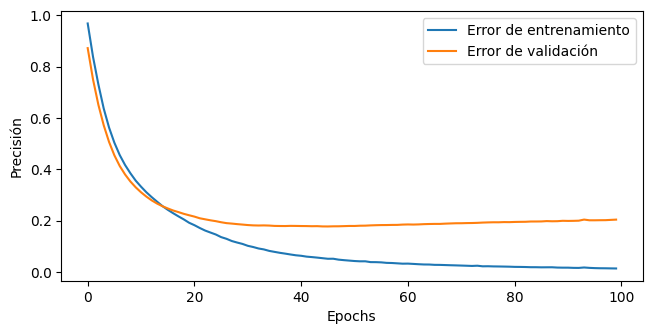

In [14]:
import matplotlib.pyplot as plt

# Evaluar el modelo
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Precisión en el conjunto de prueba: {accuracy:.2f}")

# Grafica
plt.plot(history.history['loss'], label='Error de entrenamiento')
plt.plot(history.history['val_loss'], label='Error de validación')
plt.xlabel('Epochs')
plt.ylabel('Precisión')
plt.legend()
plt.show()

**Métricas de evaluación**

In [15]:
from sklearn.metrics import classification_report

y_pred = model.predict(X_test)

print(
    classification_report(
        np.argmax(y_test, axis=1),
        np.argmax(y_pred, axis=1),
    )
)



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         6
           1       1.00      1.00      1.00         6
           2       1.00      1.00      1.00         3

    accuracy                           1.00        15
   macro avg       1.00      1.00      1.00        15
weighted avg       1.00      1.00      1.00        15



## Ejercicio - Tensorflow playground

https://playground.tensorflow.org/

<br>


# 2 - Deep Learning



Debido a la gran capacidad de aprendizaje de las redes neuronales, se vio que no solamente valían para problemas de predicción / clasificación numérica, sino que además también funcionaba para otro tipo de tareas como

 * Detección de objetos en una imagen
 * Generación de imagen / audio / vídeo
 * Sistemas capaces de hablar y entender

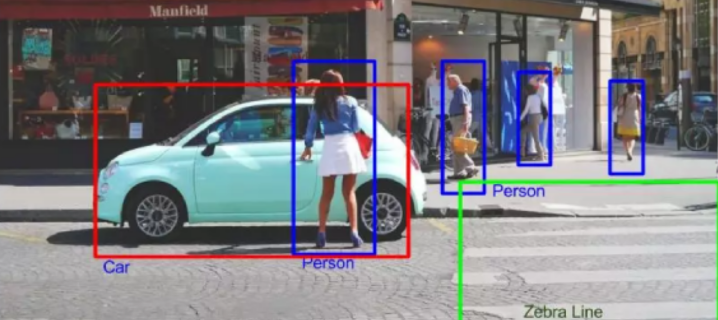

Para referirse a cuando usamos redes neuronales para problemas de Machine Learning donde el objetivo esresolver tareas más "abstractas" que simplemente una predicción numérica, se denomina **Deep Learning**. El Deep Learning se construye a través de redes neuronales, pero no todas las redes neuronales tiene que ser Deep learning:

<br>

* **¿Cuándo es Machine Learning?**: Cuando usamos una red neuronal con menos de 3 capas de neuronas para hacer predicción numérica.

<br>


* **¿Cuándo es Deep Learning?**: Cuando usamos una red neuronal con un alto número de neuronas y datos, con el objetivo de que sea capaz de resolver tareas más abstractas que una predicción numérica

<br>


## 2.1 - Word2vec - Implementación

Word2vec es un algoritmo que sirve para hacer word-embeddings de palabras. Básicamente este algoritmo trata, por medio de redes neuronales a tratar de predecir para cada palabra del corpus, la ventana de contexto de palabras que aparecen a su alrededor. De esta manera, una vez la red neuronal ha sido entrenada, a partir de los parámetros de las neuronas podemos construir un vector que representa el "significado" de esa palabra

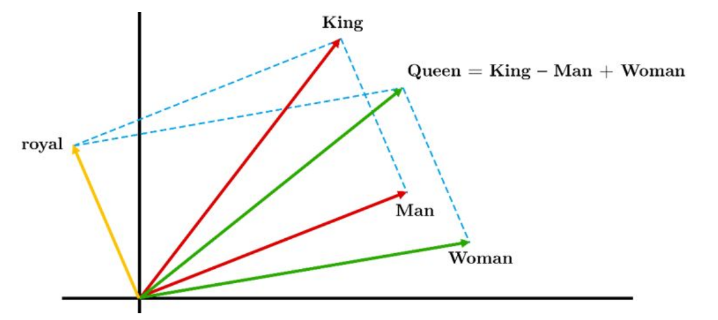

### Dataset - 100 Años de soledad

In [16]:
import requests

text = requests.get('https://gist.githubusercontent.com/ismaproco/6781d297ee65c6a707cd3c901e87ec56/raw/20d3520cd7c53d99215845375b1dca16ac827bd7/gabriel_garcia_marquez_cien_annos_soledad.txt').content.decode()
text = text[0:len(text)//10]
print(text[0:1000])

Gabriel García Márquez 



Cien años de soledad 



EDITADO POR "EDICIONES LA CUEVA" 



Para J omi García Ascot 
y María Luisa Elio 



Cien años de soledad 



Gabriel García Márquez 



Muchos años después, frente al pelotón de fusilamiento, el coronel Aureliano Buendía había de 
recordar aquella tarde remota en que su padre lo llevó a conocer el hielo. Macondo era entonces 
una aldea de veinte casas de barro y cañabrava construidas a la orilla de un río de aguas diáfanas 
que se precipitaban por un lecho de piedras pulidas, blancas y enormes como huevos 
prehistóricos. El mundo era tan reciente, que muchas cosas carecían de nombre, y para 
mencionarlas había que señalarías con el dedo. Todos los años, por el mes de marzo, una familia 
de gitanos desarrapados plantaba su carpa cerca de la aldea, y con un grande alboroto de pitos y 
timbales daban a conocer los nuevos inventos. Primero llevaron el imán. Un gitano corpulento, de 
barba montaraz y manos de gorrión, que se presentó con 

<br>


### Preprocesamiento - SkipN-gram

**Preprocesamiento**

In [17]:
import re
from nltk.tokenize import word_tokenize

def preprocess(text):

    # Elimina pie de página
    pie_de_pagina = "\n\n\nCien años de soledad \n\n\n\nGabriel García Márquez \n\n"
    text = " ".join(text.split(pie_de_pagina)[1:])

    # Combinar palabras cortadas
    text = text.replace("- \n","")

    # Convierte a minúsculas
    text = text.lower()

    # Eliminar puntuación excepto "."
    text = re.sub(r'[^\w\s.]', '', text)

    # Replazar números por XXX
    text = re.sub(r"\d+", "xxx", text)

    # Elimina saltos de línea
    text = text.replace("\n", "")

    return text

In [18]:
corpus = preprocess(text)
corpus = [text for text in corpus.split('. ') if len(text.split())>5]
print(corpus[0])

muchos años después frente al pelotón de fusilamiento el coronel aureliano buendía había de recordar aquella tarde remota en que su padre lo llevó a conocer el hielo


**Vocabulario**

In [22]:
def build_vocab(corpus):
    words = sorted(set(word for text in corpus for word in text.split()))
    vocab = {word: i for i, word in enumerate(words)}

    return vocab

vocab = build_vocab(corpus)
print({a:b for a,b in vocab.items() if b<30})

{'a': 0, 'abalorios': 1, 'abandonaba': 2, 'abandonada': 3, 'abandonado': 4, 'abandonados': 5, 'abandonar': 6, 'abandonaron': 7, 'abandonó': 8, 'abastecerse': 9, 'abejas': 10, 'abiertas': 11, 'abierto': 12, 'abiertos': 13, 'abismo': 14, 'abnegación': 15, 'abriendo': 16, 'abrir': 17, 'abrió': 18, 'abrumados': 19, 'absoluta': 20, 'absorbente': 21, 'absorta': 22, 'absorto': 23, 'abuelo': 24, 'abuelos': 25, 'aburrido': 26, 'acababa': 27, 'acaban': 28, 'acabara': 29}


**Tokenización**

In [23]:
def tokenize(text, vocab):
    tokens = []
    for word in text.split():
        if word in vocab:
            tokens.append(vocab[word])
    return tokens


tokens = [tokenize(text,vocab) for text in corpus]
print(tokens[0])

[2190, 353, 1013, 1501, 100, 2465, 865, 1524, 1140, 766, 331, 418, 1602, 865, 2820, 237, 3229, 2865, 1171, 2748, 3171, 2383, 1988, 1984, 0, 694, 1140, 1647]


<br>

**Skip-ngrams**

El algoritmo de skip-ngram consiste en modelar un corpus de manera que para cada palabra del corpus guardemos el par "palabra-contexto". Denominamos contexto al conjunto de palabras que aparecen en un entorno alrededor de esa palabra

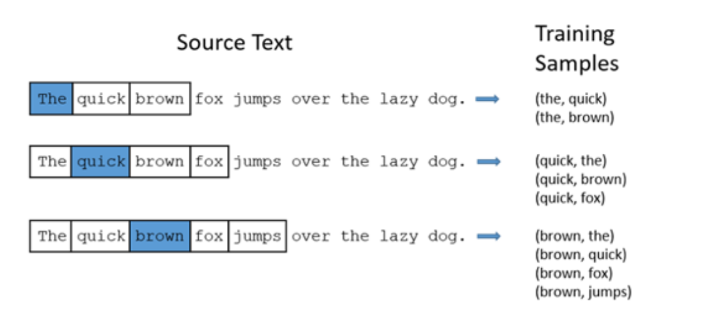

In [24]:
import numpy as np

def skip_ngram(tokens, vocab_size, window_size=2):

    n_samples = sum([(len(sequence)-2*window_size) for sequence in tokens])
    targets = np.zeros((n_samples,vocab_size), dtype=np.int8)
    context = np.zeros((n_samples,vocab_size), dtype=np.int8)

    row_idx=0
    for sequence in tokens:
        for target_idx in range(window_size,len(sequence)-window_size):
            for context_idx in range(-window_size,window_size+1):
                if context_idx != 0:
                    targets[row_idx, sequence[target_idx]] = 1
                    context[row_idx, sequence[target_idx+context_idx]] += 1
            row_idx+=1

    return targets, context

targets, context = skip_ngram(tokens, vocab_size=len(vocab), window_size=2)

Vamos a ver cómo funciona esta movida

In [25]:
sample_vocab = [0,1,2]
sample_tokens = [
    [0,0,2,0,0],
]

sample_targets, sample_context = skip_ngram(
    tokens=sample_tokens,
    vocab_size=len(sample_vocab),
    window_size=2,
)

print("La frase")
print(sample_tokens[0],"\n")

print("El token '2' (un '1' en la posición '2')...")
print(sample_targets,"\n")

print("...tiene como contexto '4' tokens '0'")
print(sample_context,"\n")

La frase
[0, 0, 2, 0, 0] 

El token '2' (un '1' en la posición '2')...
[[0 0 1]] 

...tiene como contexto '4' tokens '0'
[[4 0 0]] 



### Modelo - Word2vec

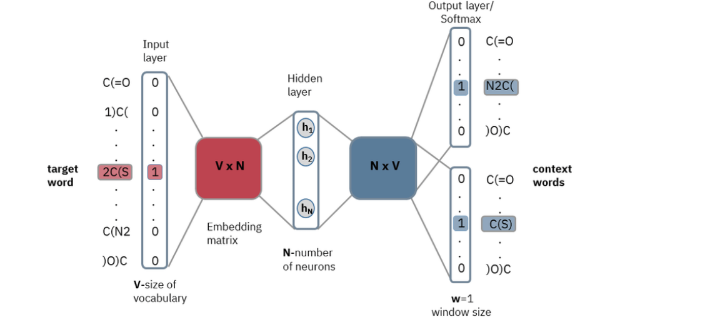

Existen diferentes implementaciones, pero de manera más o menos general el algoritmo de word2vec consiste en una red neuronal de 2 capas.

In [26]:
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Sequential

epochs = 10
batch_size = 64
embedding_dim=30

model = Sequential([
    Dense(embedding_dim, input_dim=len(vocab), activation=None, use_bias=False),
    Dense(len(vocab), activation='softmax')
])

model.compile(
    optimizer=Adam(learning_rate=0.01),
    loss='binary_crossentropy',
)

model.fit(
    targets,
    context,
    epochs=epochs,
    batch_size=batch_size,
    verbose=1,
)

Epoch 1/10


/home/thinbaker/Workspace/Curso-de-IA-y-NLP/.venv/lib/python3.13/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


181/181 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.2120
Epoch 2/10
181/181 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0180
Epoch 3/10
181/181 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0086
Epoch 4/10
181/181 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0074
Epoch 5/10
181/181 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0070
Epoch 6/10
181/181 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0068
Epoch 7/10
181/181 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0066
Epoch 8/10
181/181 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0066
Epoch 9/10
181/181 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0065
Epoch 10/10
181/181 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0065


<br>


Una vez que hemos entrenado la red para ser capaz de predecir el contexto a partir de cada palabra, extraemos los parámetros de las neuronas de la primera capa. Se ha demostrado que estos parámetros resultan ser una buena representación numérica del significado de la palabra, de ahí que este tipo de algoritmos funcionen tan bien

In [27]:
import pandas as pd

embeddings = model.get_weights()[0] #model.get_embeddings()

pd.DataFrame(embeddings, index=list(vocab))

,0,1,2,3,4,5,6,7,8,9,...,20,21,22,23,24,25,26,27,28,29
a,0.234406,-0.126122,0.246243,0.208663,-0.166405,0.322598,0.220155,0.133592,-0.104486,0.159199,...,0.246889,-0.080693,-0.164623,0.316190,-0.176795,-0.259360,-0.206756,-0.207212,-0.081598,0.181170
abalorios,0.171939,-0.178400,0.164575,0.167581,-0.174821,0.162288,0.165506,0.160353,-0.197166,0.218980,...,0.216746,-0.221732,-0.214416,0.199305,-0.188701,-0.164878,-0.168847,-0.221191,-0.204140,0.194162
abandonaba,0.209250,-0.194660,0.180136,0.140798,-0.167366,0.187678,0.171917,0.183339,-0.201658,0.174533,...,0.185801,-0.218426,-0.205336,0.148821,-0.184863,-0.217534,-0.225795,-0.190077,-0.198849,0.227397
abandonada,0.229920,-0.191245,0.178878,0.217497,-0.219516,0.222006,0.173896,0.237267,-0.220348,0.212111,...,0.158629,-0.198642,-0.198807,0.152547,-0.204054,-0.213594,-0.209652,-0.234661,-0.201804,0.210493
abandonado,0.170507,-0.140090,0.173850,0.142312,-0.153821,0.183942,0.187751,0.194928,-0.185696,0.201957,...,0.188775,-0.188732,-0.166952,0.196778,-0.148130,-0.157741,-0.183040,-0.136895,-0.177463,0.187649
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
única,0.167178,-0.139718,0.158496,0.195451,-0.213560,0.195811,0.190464,0.166292,-0.208295,0.144643,...,0.144962,-0.201990,-0.210051,0.144588,-0.154215,-0.203786,-0.144960,-0.180691,-0.197660,0.163747
único,0.155135,-0.164492,0.196074,0.169758,-0.208785,0.193962,0.217298,0.251632,-0.224706,0.178224,...,0.205550,-0.190638,-0.173600,0.165011,-0.231385,-0.182330,-0.176701,-0.220062,-0.156330,0.201969
únicos,0.009182,0.028055,0.016810,0.037318,0.039544,-0.020686,-0.016528,0.011857,-0.036342,0.012789,...,0.031795,0.027112,0.006989,-0.003202,-0.034240,-0.031660,-0.016814,-0.010818,0.018560,-0.012210
úrsula,0.220119,-0.157743,0.209474,0.230965,-0.157070,0.196174,0.279151,0.219750,-0.171402,0.172075,...,0.137741,-0.174594,-0.152491,0.177689,-0.177951,-0.218779,-0.132982,-0.168852,-0.237571,0.200629


<br>

### Evaluación - Similitud vectorial

Vamos a probar a buscar "palabras similares" a una dada a partir de un algoritmo de búsqueda de similitud del coseno como el que vimos en la sesión de machine learning

In [28]:
def find_closest_embeddings(embeddings, word, vocab, top_n=3):

    word2idx = vocab
    idx2word = {idx: word for word, idx in word2idx.items()}

    word_idx = word2idx[word]
    word_vec = embeddings[word_idx]

    similarities = {}
    for idx in range(len(embeddings)):
        similarities[idx2word[idx]] = np.dot(word_vec, embeddings[idx]) / (
            np.linalg.norm(word_vec) * np.linalg.norm(embeddings[idx])
        )

    sorted_similarities = sorted(similarities.items(), key=lambda x: -x[1])
    return sorted_similarities[1 : top_n + 1]  # Excluir la palabra original

In [29]:
# Probar la búsqueda de palabras similares
print(find_closest_embeddings(embeddings, "arcadio", vocab))

[('buendia', np.float32(0.9293387)), ('buendía', np.float32(0.90647125)), ('josé', np.float32(0.90549725))]


In [32]:
# Probar la búsqueda de palabras similares
print(find_closest_embeddings(embeddings, "casa", vocab))

[('aldea', np.float32(0.97823995)), ('preguntaran', np.float32(0.97670746)), ('noche', np.float32(0.97639745))]


<br>


## 2.2 - Word2vec - Embeddings precalculados

En la sección anterior hemos visto como funcionan las redes neuronales y como podemos usarlas para crear embeddings. Sin embargo, en el mundo real es más común usar vectores preentrenados. Una entrenamiento muy común de word2vec es el google news entrenado sobre un vocabulario de 300.000 palabras

### Gensim

Gensim es una librería de NLP pensaba para trabajar principalmente con embeddings de redes neuronales

In [33]:
#!pip install -q gensim
import gensim.downloader as api
wv = api.load('word2vec-google-news-300')

In [34]:
for index, word in enumerate(wv.index_to_key[0:10]):
    print(f"word #{index}/{len(wv.index_to_key)} is {word}")

word #0/3000000 is </s>
word #1/3000000 is in
word #2/3000000 is for
word #3/3000000 is that
word #4/3000000 is is
word #5/3000000 is on
word #6/3000000 is ##
word #7/3000000 is The
word #8/3000000 is with
word #9/3000000 is said


<br>

### Similitud entre palabras

In [35]:
pairs = [
    ('car', 'minivan'),   # a minivan is a kind of car
    ('car', 'bicycle'),   # still a wheeled vehicle
    ('car', 'airplane'),  # ok, no wheels, but still a vehicle
    ('car', 'cereal'),    # ... and so on
    ('car', 'communism'),
]
for w1, w2 in pairs:
    print('%r\t%r\t%.2f' % (w1, w2, wv.similarity(w1, w2)))

'car'	'minivan'	0.69
'car'	'bicycle'	0.54
'car'	'airplane'	0.42
'car'	'cereal'	0.14
'car'	'communism'	0.06


**Palabras parecidas**

In [36]:
print(wv.most_similar(positive=['car', 'minivan'], topn=5))

[('SUV', 0.8532192707061768), ('vehicle', 0.8175783753395081), ('pickup_truck', 0.7763688564300537), ('Jeep', 0.7567334175109863), ('Ford_Explorer', 0.7565720081329346)]


### Relaciones ternarias

 **Capitales de países**

In [37]:
vector = wv["Spain"] - wv["Madrid"] + wv["Paris"]
word_1, word_2, word_3, word_4 = 'Spain Madrid Paris France'.split()

vector = wv[word_1] - wv[word_2] + wv[word_3]
wv.most_similar([vector], topn=3)

[('France', 0.7308870553970337),
 ('Paris', 0.6799718737602234),
 ('Belgium', 0.5709303021430969)]

**Monedas y países**

In [38]:
word_1, word_2, word_3, word_4 = 'Canada dollar Sweden krona'.split()

vector = wv[word_1] - wv[word_2] + wv[word_3]
wv.most_similar([vector], topn=3)

[('Sweden', 0.7631871104240417),
 ('Canada', 0.6770985722541809),
 ('Finland', 0.6654629707336426)]

**Relaciones Familiares**

In [39]:
word_1, word_2, word_3, word_4 = 'boy girl brothers sisters'.split()

vector = wv[word_1] - wv[word_2] + wv[word_3]
wv.most_similar([vector], topn=3)

[('brothers', 0.9034602642059326),
 ('brother', 0.7073572278022766),
 ('sons', 0.6744694709777832)]

**gram1-adjective-to-adverb**

In [40]:
word_1, word_2, word_3, word_4 = 'amazing amazingly typical typically'.split()

vector = wv[word_1] - wv[word_2] + wv[word_3]
wv.most_similar([vector], topn=3)

[('typical', 0.7252750396728516),
 ('amazing', 0.5572218298912048),
 ('unbelievable', 0.5250348448753357)]

**comparative**

In [41]:
word_1, word_2, word_3, word_4 = 'bad worse big bigger'.split()

vector = wv[word_1] - wv[word_2] + wv[word_3]
wv.most_similar([vector], topn=3)

[('big', 0.7234302759170532),
 ('huge', 0.5404797196388245),
 ('bad', 0.505824863910675)]

**superlative**

In [42]:
word_1, word_2, word_3, word_4 = 'bad worst big biggest'.split()

vector = wv[word_1] - wv[word_2] + wv[word_3]
wv.most_similar([vector], topn=3)

[('big', 0.6512065529823303),
 ('bad', 0.5393273234367371),
 ('good', 0.5252904295921326)]

**present participle**

In [43]:
word_1, word_2, word_3, word_4 = 'code coding dance dancing'.split()

vector = wv[word_1] - wv[word_2] + wv[word_3]
wv.most_similar([vector], topn=3)

[('dance', 0.6756331324577332),
 ('dances', 0.580110490322113),
 ('dancing', 0.5672891139984131)]

<br>

## 2.3 - Clasificador con embeddings

Fasttext ese una librería que permite usar las capacidades de redes neuronales sin necesidad de tener que programar directamente la red neuronal. Esto simplifica mucho tareas como por ejemplo, hacer un clasificador de texto

### Fake News Dataset

Un uso muy común del uso del NLP a día de hoy es el de poder monitorizar fuentes escritas de internt como puede ser blogs, redes sociales o prensa escrita. Un problema muy común durante estos últimos años la detección automática de noticias falsas.

Fake news dataset es un corpus que contiene diferentes registros de textos de prensa escrita en español sobre diferentes noticias. Estos textos están etiquetados tanto con la temática de la noticia como con si la noticia es o no fake

In [44]:
import pandas as pd

data = pd.read_csv("hf://datasets/mariagrandury/fake_news_corpus_spanish/test.csv")
data.head()

/home/thinbaker/Workspace/Curso-de-IA-y-NLP/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,ID,CATEGORY,TOPICS,SOURCE,HEADLINE,TEXT,LINK
0,1,True,Covid-19,El Economista,Covid-19: mentiras que matan,El control de la Covid-19 no es sólo un tema d...,https://www.eleconomista.com.mx/opinion/Covid-...
1,2,False,Política,El matinal,El Gobierno podrá acceder a las IPs de los móv...,El Gobierno de Pedro Sánchez y Pablo Iglesias ...,https://www.elmatinal.com/espana-ultima-hora/e...
2,3,True,Política,El País,La comunidad musulmana catalana denuncia a Vox...,Las tres federaciones que agrupan al 90% de la...,https://elpais.com/espana/elecciones-catalanas...
3,4,False,Política,AFPFactual,NaN,Se han dado a conocer los datos electorales pr...,https://perma.cc/GYE6-SPMB
4,5,True,Sociedad,La Republica,El censo poblacional 2018 tendrá un costo de $...,La primera fase del censo será virtual y solo ...,https://www.larepublica.co/economia/el-censo-p...


### Preprocesamiento

In [45]:
def preprocess(data):

    data['text'] = data.TEXT.str.replace("\n", " ")
    data['labels'] = data.TOPICS.apply(lambda x: "__label__" + x)

    return data[["text","labels"]]

corpus = preprocess(data)
corpus

,text,labels
0,El control de la Covid-19 no es sólo un tema d...,__label__Covid-19
1,El Gobierno de Pedro Sánchez y Pablo Iglesias ...,__label__Política
2,Las tres federaciones que agrupan al 90% de la...,__label__Política
3,Se han dado a conocer los datos electorales pr...,__label__Política
4,La primera fase del censo será virtual y solo ...,__label__Sociedad
...,...,...
567,El Instituto de Diagnóstico y Referencia Epide...,__label__Covid-19
568,La hija del rey Felipe y de la reina Letizia y...,__label__Sociedad
569,"Evidentemente, Barak Obama ha sido arrestado e...",__label__Política
570,El Ministerio de Sanidad ha actualizado los da...,__label__Covid-19


In [46]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    corpus.text.to_list(),
    corpus.labels.to_list(),
    test_size=0.2,
    random_state=42)

### Modelo

**Guardamos el dataset**: Fasttext trabaja sobre archivos guardados, no sobre variables en memoria

In [47]:
with open("data.txt", "w") as f:
    for text, label in zip(X_train, y_train):
        f.write(f"{label} {text}\n")

**Entrenamiento**

In [52]:
!pip install -q fasttext
import fasttext

model = fasttext.train_supervised(
    "data.txt",
    lr=1.0,
    epoch=25,
    wordNgrams=2,
)

Read 0M words
Number of words:  39128
Number of labels: 6
Progress: 100.0% words/sec/thread:  945898 lr:  0.000000 avg.loss:  0.884497 ETA:   0h 0m 0s


### Predicción

In [53]:
y_pred, y_pred_proba = model.predict(X_test)
print("Predictions:\t", y_pred)
print("Probabilities:\t", y_pred_proba)

Predictions:	 [['__label__Sociedad'], ['__label__Política'], ['__label__Covid-19'], ['__label__Sociedad'], ['__label__Covid-19'], ['__label__Covid-19'], ['__label__Sociedad'], ['__label__Sociedad'], ['__label__Política'], ['__label__Sociedad'], ['__label__Sociedad'], ['__label__Sociedad'], ['__label__Sociedad'], ['__label__Sociedad'], ['__label__Covid-19'], ['__label__Covid-19'], ['__label__Covid-19'], ['__label__Covid-19'], ['__label__Sociedad'], ['__label__Covid-19'], ['__label__Sociedad'], ['__label__Covid-19'], ['__label__Covid-19'], ['__label__Covid-19'], ['__label__Sociedad'], ['__label__Sociedad'], ['__label__Covid-19'], ['__label__Sociedad'], ['__label__Covid-19'], ['__label__Sociedad'], ['__label__Política'], ['__label__Covid-19'], ['__label__Covid-19'], ['__label__Sociedad'], ['__label__Covid-19'], ['__label__Covid-19'], ['__label__Sociedad'], ['__label__Covid-19'], ['__label__Sociedad'], ['__label__Sociedad'], ['__label__Covid-19'], ['__label__Covid-19'], ['__label__Sociedad

### Evaluation

In [54]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

                        precision    recall  f1-score   support

    __label__Ambiental       0.00      0.00      0.00         0
      __label__Ciencia       0.00      0.00      0.00         3
     __label__Covid-19       0.77      0.86      0.81        50
      __label__Deporte       0.00      0.00      0.00         2
__label__Internacional       0.00      0.00      0.00         3
     __label__Política       0.50      0.14      0.22        14
     __label__Sociedad       0.59      0.74      0.66        43

              accuracy                           0.67       115
             macro avg       0.27      0.25      0.24       115
          weighted avg       0.62      0.67      0.63       115



/home/thinbaker/Workspace/Curso-de-IA-y-NLP/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/thinbaker/Workspace/Curso-de-IA-y-NLP/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/thinbaker/Workspace/Curso-de-IA-y-NLP/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _wa